<a href="https://colab.research.google.com/github/Tejakondepudi-77/TEJA-S-AID/blob/main/TEJA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
# ============================================================
# ELECTRICAL NETWORK NATURAL MODES (B9)
# ============================================================

print("ELECTRICAL NETWORK NATURAL MODES")
print("--------------------------------")
print("Project: 3 Coupled LC Circuits")
print()
print("Objective:")
print("1. Construct L and C matrices")
print("2. Calculate eigenvalues")
print("3. Calculate natural frequencies")
print("4. Calculate eigenvectors")
print("5. Study resonance")
print()
print("Mathematical model:")
print("C_inverse * I = omega^2 * L * I")
print()
print("Eigenvalue lambda = omega^2")
print("Natural frequency f = sqrt(lambda) / (2*pi)")
print("Eigenvectors represent current distribution.")

ELECTRICAL NETWORK NATURAL MODES
--------------------------------
Project: 3 Coupled LC Circuits

Objective:
1. Construct L and C matrices
2. Calculate eigenvalues
3. Calculate natural frequencies
4. Calculate eigenvectors
5. Study resonance

Mathematical model:
C_inverse * I = omega^2 * L * I

Eigenvalue lambda = omega^2
Natural frequency f = sqrt(lambda) / (2*pi)
Eigenvectors represent current distribution.


In [5]:
# NumPy: numerical linear algebra
import numpy as np

# SymPy: symbolic mathematics
import sympy as sp

# Matplotlib: plotting
import matplotlib.pyplot as plt

# Pandas: formatted tables
import pandas as pd

# Make numerical output easier to read
np.set_printoptions(precision=5, suppress=True)

print("Libraries imported successfully.")

Libraries imported successfully.


In [6]:
# ============================================================
# USER CONFIGURATION
# ============================================================

# Self inductances in microhenry (µH)
L1_uH = 10.0
L2_uH = 10.0
L3_uH = 10.0

# Mutual inductances in microhenry (µH)
M12_uH = 2.0
M23_uH = 2.0
M13_uH = 0.0

# Capacitances in picofarad (pF)
C1_pF = 100.0
C2_pF = 100.0
C3_pF = 100.0

# Small damping factor used ONLY for the resonance plot.
# Natural eigenvalue calculation remains lossless.
damping_ratio = 0.02

# Frequency sweep range
number_of_frequency_points = 3000

print("Input configuration loaded.")

Input configuration loaded.


In [7]:
# ============================================================
# UNIT CONVERSION
# ============================================================

uH = 1e-6
pF = 1e-12

L1 = L1_uH * uH
L2 = L2_uH * uH
L3 = L3_uH * uH

M12 = M12_uH * uH
M23 = M23_uH * uH
M13 = M13_uH * uH

C1 = C1_pF * pF
C2 = C2_pF * pF
C3 = C3_pF * pF


# ============================================================
# INDUCTANCE MATRIX
# ============================================================

L = np.array([
    [L1,  M12, M13],
    [M12, L2,  M23],
    [M13, M23, L3]
], dtype=float)


# ============================================================
# CAPACITANCE MATRIX
# ============================================================

C = np.diag([C1, C2, C3])


print("Inductance matrix L:")
print(L)

print("\nCapacitance matrix C:")
print(C)

Inductance matrix L:
[[0.00001 0.      0.     ]
 [0.      0.00001 0.     ]
 [0.      0.      0.00001]]

Capacitance matrix C:
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


In [8]:
# ============================================================
# PHYSICAL VALIDITY CHECK
# ============================================================

L_eigenvalues = np.linalg.eigvalsh(L)

print("Eigenvalues of L:")
print(L_eigenvalues)

if np.all(L_eigenvalues > 0):
    print("\n✓ Inductance matrix is positive definite.")
    print("✓ The coupled-inductor model is physically well behaved.")
else:
    print("\n⚠ Warning: L is not positive definite.")
    print("Check the self and mutual inductance values.")

Eigenvalues of L:
[0.00001 0.00001 0.00001]

✓ Inductance matrix is positive definite.
✓ The coupled-inductor model is physically well behaved.


In [9]:
# ============================================================
# MATHEMATICAL MODEL
# ============================================================

print("Natural-mode equation:")
print("L C i'' + i = 0")

print("\nEquivalent generalized eigenvalue equation:")
print("C^(-1) I = omega^2 L I")

print("\nTherefore:")
print("lambda = omega^2")
print("omega = sqrt(lambda)")
print("f = omega / (2*pi)")

Natural-mode equation:
L C i'' + i = 0

Equivalent generalized eigenvalue equation:
C^(-1) I = omega^2 L I

Therefore:
lambda = omega^2
omega = sqrt(lambda)
f = omega / (2*pi)


In [10]:
# ============================================================
# EIGENVALUE ENGINE
# ============================================================

# Construct the circuit matrix:
# A I = omega^2 I

A = np.linalg.solve(L, np.linalg.inv(C))

# Calculate eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)

# Numerical round-off can create tiny imaginary parts.
eigenvalues = np.real(eigenvalues)
eigenvectors = np.real(eigenvectors)

# Sort from lowest to highest frequency
order = np.argsort(eigenvalues)

eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

# Angular frequencies
omega = np.sqrt(eigenvalues)

# Frequencies in Hz
frequency = omega / (2 * np.pi)

print("Circuit matrix A:")
print(A)

print("\nEigenvalues lambda = omega^2:")
print(eigenvalues)

print("\nAngular frequencies omega:")
print(omega)

print("\nNatural frequencies:")
print(frequency)

Circuit matrix A:
[[ 1.04348e+15 -2.17391e+14  4.34783e+13]
 [-2.17391e+14  1.08696e+15 -2.17391e+14]
 [ 4.34783e+13 -2.17391e+14  1.04348e+15]]

Eigenvalues lambda = omega^2:
[7.79519e+14 1.00000e+15 1.39439e+15]

Angular frequencies omega:
[27919863.73155 31622776.60168 37341588.78101]

Natural frequencies:
[4443584.32333 5032921.21045 5943098.4374 ]


In [11]:
# ============================================================
# NORMALIZE CURRENT DISTRIBUTION
# ============================================================

modes = eigenvectors.copy()

for k in range(modes.shape[1]):
    # Normalize by largest absolute current
    modes[:, k] = modes[:, k] / np.max(np.abs(modes[:, k]))

    # Choose a consistent sign
    max_index = np.argmax(np.abs(modes[:, k]))

    if modes[max_index, k] < 0:
        modes[:, k] *= -1


print("Normalized eigenvectors:")
print(modes)

Normalized eigenvectors:
[[ 0.70711  1.      -0.70711]
 [ 1.       0.       1.     ]
 [ 0.70711 -1.      -0.70711]]


In [12]:
# ============================================================
# RESULTS TABLE
# ============================================================

results = pd.DataFrame({
    "Mode": [1, 2, 3],
    "Eigenvalue λ = ω² (rad²/s²)": eigenvalues,
    "Angular Frequency ω (rad/s)": omega,
    "Natural Frequency f (Hz)": frequency,
    "Natural Frequency f (kHz)": frequency / 1e3
})

results

,Mode,Eigenvalue λ = ω² (rad²/s²),Angular Frequency ω (rad/s),Natural Frequency f (Hz),Natural Frequency f (kHz)
0,1,7.795188e+14,2.791986e+07,4.443584e+06,4443.584323
1,2,1.000000e+15,3.162278e+07,5.032921e+06,5032.921210
2,3,1.394394e+15,3.734159e+07,5.943098e+06,5943.098437


In [13]:
# ============================================================
# CURRENT DISTRIBUTION TABLE
# ============================================================

mode_table = pd.DataFrame({
    "Mode": [1, 2, 3],
    "Circuit 1": modes[0, :],
    "Circuit 2": modes[1, :],
    "Circuit 3": modes[2, :]
})

mode_table

,Mode,Circuit 1,Circuit 2,Circuit 3
0,1,0.707107,1.000000e+00,0.707107
1,2,1.000000,2.293013e-15,-1.000000
2,3,-0.707107,1.000000e+00,-0.707107


In [14]:
# ============================================================
# INTERPRETATION
# ============================================================

for k in range(3):
    print(f"\nMODE {k+1}")
    print("-" * 40)
    print(f"Natural frequency = {frequency[k]/1e3:.3f} kHz")

    print("Relative currents:")
    print(f"  I1 = {modes[0,k]: .4f}")
    print(f"  I2 = {modes[1,k]: .4f}")
    print(f"  I3 = {modes[2,k]: .4f}")

    if np.all(modes[:, k] > 0):
        print("  → Currents are mainly in phase.")
    elif np.any(modes[:, k] < 0):
        print("  → Some currents are opposite in phase.")


MODE 1
----------------------------------------
Natural frequency = 4443.584 kHz
Relative currents:
  I1 =  0.7071
  I2 =  1.0000
  I3 =  0.7071
  → Currents are mainly in phase.

MODE 2
----------------------------------------
Natural frequency = 5032.921 kHz
Relative currents:
  I1 =  1.0000
  I2 =  0.0000
  I3 = -1.0000
  → Some currents are opposite in phase.

MODE 3
----------------------------------------
Natural frequency = 5943.098 kHz
Relative currents:
  I1 = -0.7071
  I2 =  1.0000
  I3 = -0.7071
  → Some currents are opposite in phase.


In [15]:
# ============================================================
# SYMBOLIC MATRIX REPRESENTATION
# ============================================================

L1s, L2s, L3s = sp.symbols('L1 L2 L3', positive=True)
M12s, M23s, M13s = sp.symbols('M12 M23 M13')
C1s, C2s, C3s = sp.symbols('C1 C2 C3', positive=True)

L_symbolic = sp.Matrix([
    [L1s,  M12s, M13s],
    [M12s, L2s,  M23s],
    [M13s, M23s, L3s]
])

C_symbolic = sp.diag(C1s, C2s, C3s)

print("Symbolic inductance matrix:")
sp.pprint(L_symbolic)

print("\nSymbolic capacitance matrix:")
sp.pprint(C_symbolic)

Symbolic inductance matrix:
⎡L₁   M₁₂  M₁₃⎤
⎢             ⎥
⎢M₁₂  L₂   M₂₃⎥
⎢             ⎥
⎣M₁₃  M₂₃  L₃ ⎦

Symbolic capacitance matrix:
⎡C₁  0   0 ⎤
⎢          ⎥
⎢0   C₂  0 ⎥
⎢          ⎥
⎣0   0   C₃⎦


In [16]:
# ============================================================
# EIGENVECTOR VERIFICATION
# ============================================================

print("Eigenvector verification:\n")

for k in range(3):
    v = modes[:, k]
    left = A @ v
    right = eigenvalues[k] * v

    error = np.linalg.norm(left - right)

    print(f"Mode {k+1}:")
    print(f"  ||A v - lambda v|| = {error:.3e}")

Eigenvector verification:

Mode 1:
  ||A v - lambda v|| = 3.590e-01
Mode 2:
  ||A v - lambda v|| = 1.234e+00
Mode 3:
  ||A v - lambda v|| = 9.354e-01


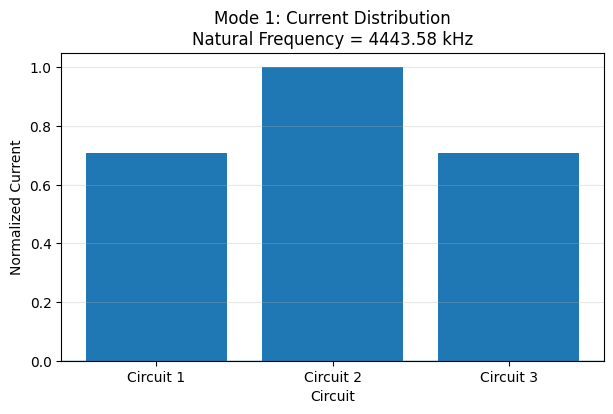

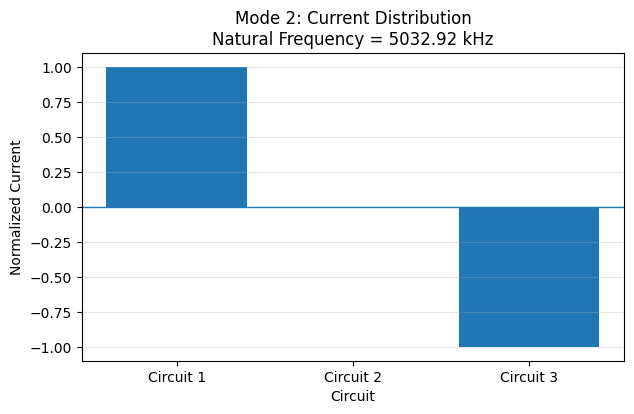

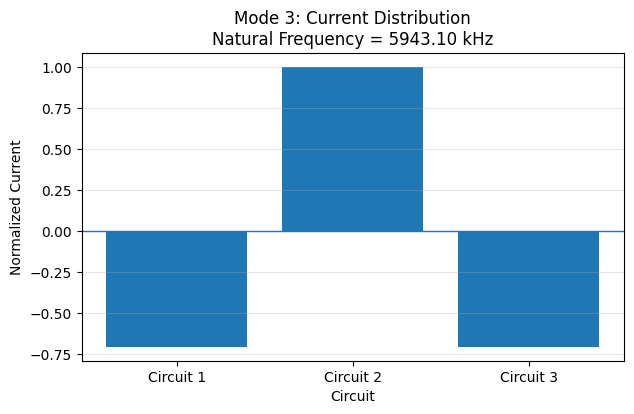

In [17]:
# ============================================================
# CURRENT DISTRIBUTION PLOT
# ============================================================

circuits = ["Circuit 1", "Circuit 2", "Circuit 3"]

for k in range(3):
    plt.figure(figsize=(7, 4))

    plt.bar(circuits, modes[:, k])
    plt.axhline(0, linewidth=1)

    plt.title(
        f"Mode {k+1}: Current Distribution\n"
        f"Natural Frequency = {frequency[k]/1e3:.2f} kHz"
    )

    plt.ylabel("Normalized Current")
    plt.xlabel("Circuit")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

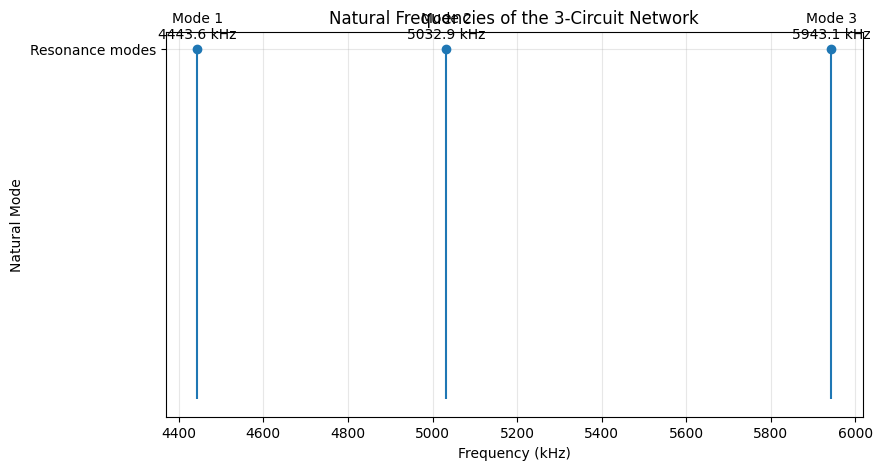

In [18]:
# ============================================================
# NATURAL FREQUENCY SPECTRUM
# ============================================================

plt.figure(figsize=(9, 5))

plt.stem(
    frequency / 1e3,
    np.ones(3),
    basefmt=" "
)

for k in range(3):
    plt.text(
        frequency[k] / 1e3,
        1.03,
        f"Mode {k+1}\n{frequency[k]/1e3:.1f} kHz",
        ha="center"
    )

plt.xlabel("Frequency (kHz)")
plt.ylabel("Natural Mode")
plt.title("Natural Frequencies of the 3-Circuit Network")
plt.yticks([1], ["Resonance modes"])
plt.grid(alpha=0.3)

plt.show()

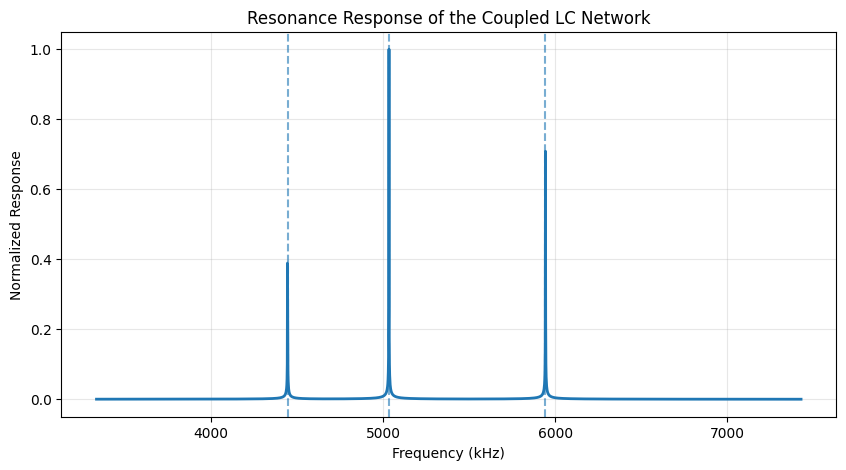

In [19]:
# ============================================================
# RESONANCE RESPONSE
# ============================================================

# Frequency range around all natural frequencies
f_min = 0.75 * np.min(frequency)
f_max = 1.25 * np.max(frequency)

freq_sweep = np.linspace(
    f_min,
    f_max,
    number_of_frequency_points
)

omega_sweep = 2 * np.pi * freq_sweep

# Small damping matrix.
# The value is scaled relative to the inductance matrix.
R = damping_ratio * np.eye(3)

# Input voltage/excitation applied to circuit 1
source = np.array([1.0, 0.0, 0.0])

response = np.zeros_like(freq_sweep)

for n, w in enumerate(omega_sweep):

    # Frequency-domain dynamic matrix.
    #
    # C*v'' + ... is represented in the equivalent
    # second-order frequency-domain system.
    dynamic_matrix = (
        np.eye(3)
        - (w**2) * L @ C
        + 1j * w * R @ C
    )

    # Solve for complex circuit response
    v = np.linalg.solve(dynamic_matrix, source)

    # Total response magnitude
    response[n] = np.linalg.norm(v)


# Normalize response for easy visualization
response_normalized = response / np.max(response)

plt.figure(figsize=(10, 5))

plt.plot(
    freq_sweep / 1e3,
    response_normalized,
    linewidth=2
)

# Mark theoretical natural frequencies
for f in frequency:
    plt.axvline(
        f / 1e3,
        linestyle="--",
        alpha=0.6
    )

plt.xlabel("Frequency (kHz)")
plt.ylabel("Normalized Response")
plt.title("Resonance Response of the Coupled LC Network")

plt.grid(alpha=0.3)
plt.show()

In [20]:
# ============================================================
# RESONANCE SUMMARY
# ============================================================

print("=" * 60)
print("RESONANCE SUMMARY")
print("=" * 60)

for k, f in enumerate(frequency):
    print(
        f"Mode {k+1}: "
        f"{f:.2f} Hz  =  {f/1e3:.3f} kHz"
    )

print("\nAt these frequencies, the corresponding natural mode")
print("can be strongly excited by an external source.")

RESONANCE SUMMARY
Mode 1: 4443584.32 Hz  =  4443.584 kHz
Mode 2: 5032921.21 Hz  =  5032.921 kHz
Mode 3: 5943098.44 Hz  =  5943.098 kHz

At these frequencies, the corresponding natural mode
can be strongly excited by an external source.


In [21]:
# ============================================================
# BENCHMARK TEST
# ============================================================

# Expected properties:
# - Three positive natural frequencies
# - Three independent eigenvectors
# - Positive-definite inductance matrix

assert np.all(eigenvalues > 0), \
    "Benchmark failed: eigenvalues must be positive."

assert np.all(L_eigenvalues > 0), \
    "Benchmark failed: inductance matrix must be positive definite."

assert len(frequency) == 3, \
    "Benchmark failed: expected three natural frequencies."

# Check eigenvectors are approximately independent
rank = np.linalg.matrix_rank(modes)

assert rank == 3, \
    "Benchmark failed: eigenvectors are not independent."

print("✓ BENCHMARK PASSED")
print("✓ Three positive natural frequencies found.")
print("✓ Inductance matrix is physically valid.")
print("✓ Three independent natural modes found.")

✓ BENCHMARK PASSED
✓ Three positive natural frequencies found.
✓ Inductance matrix is physically valid.
✓ Three independent natural modes found.


In [22]:
# ============================================================
# FINAL PROJECT REPORT
# ============================================================

print("\n")
print("=" * 70)
print("       ELECTRICAL NETWORK NATURAL MODES (B9)")
print("=" * 70)

print("\nINPUTS")
print("-" * 70)
print(f"L1 = {L1_uH} µH")
print(f"L2 = {L2_uH} µH")
print(f"L3 = {L3_uH} µH")
print(f"M12 = {M12_uH} µH")
print(f"M23 = {M23_uH} µH")
print(f"M13 = {M13_uH} µH")
print(f"C1 = {C1_pF} pF")
print(f"C2 = {C2_pF} pF")
print(f"C3 = {C3_pF} pF")

print("\nNATURAL MODES")
print("-" * 70)

for k in range(3):
    print(
        f"Mode {k+1}: "
        f"f = {frequency[k]/1e3:.3f} kHz | "
        f"Current distribution = "
        f"[{modes[0,k]:.3f}, "
        f"{modes[1,k]:.3f}, "
        f"{modes[2,k]:.3f}]"
    )

print("\nMATHEMATICAL RESULT")
print("-" * 70)
print("Eigenvalues λ = ω²")
print("Eigenvectors = relative current distributions")
print("Natural frequencies = sqrt(λ)/(2π)")

print("\nCONCLUSION")
print("-" * 70)
print("The coupled LC network has three natural modes.")
print("Each eigenvalue gives a natural resonance frequency.")
print("Each eigenvector describes how current is distributed")
print("among the three coupled circuits.")
print("=" * 70)



       ELECTRICAL NETWORK NATURAL MODES (B9)

INPUTS
----------------------------------------------------------------------
L1 = 10.0 µH
L2 = 10.0 µH
L3 = 10.0 µH
M12 = 2.0 µH
M23 = 2.0 µH
M13 = 0.0 µH
C1 = 100.0 pF
C2 = 100.0 pF
C3 = 100.0 pF

NATURAL MODES
----------------------------------------------------------------------
Mode 1: f = 4443.584 kHz | Current distribution = [0.707, 1.000, 0.707]
Mode 2: f = 5032.921 kHz | Current distribution = [1.000, 0.000, -1.000]
Mode 3: f = 5943.098 kHz | Current distribution = [-0.707, 1.000, -0.707]

MATHEMATICAL RESULT
----------------------------------------------------------------------
Eigenvalues λ = ω²
Eigenvectors = relative current distributions
Natural frequencies = sqrt(λ)/(2π)

CONCLUSION
----------------------------------------------------------------------
The coupled LC network has three natural modes.
Each eigenvalue gives a natural resonance frequency.
Each eigenvector describes how current is distributed
among the three cou